# **Netflix Data: Cleaning, Analysis and Visualization**








# **Problem Statement**


To analyze Netflix’s content dataset by cleaning and preprocessing the data, and then perform exploratory data analysis (EDA) to uncover insights about content distribution, trends, and patterns such as content type (Movies vs TV Shows), top producing countries, genres, and time-based trends.



# **Tools & Technologies**

Python

Pandas

NumPy

Matplotlib

Seaborn

Scikit-learn



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier



In [ ]:
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

## Load **Dataset**

The dataset contains information about Netflix movies and TV shows, including details such as title, type, genre, country, release year, and duration. It is used to analyze content distribution, trends, and patterns across different categories on the Netflix platform.


In [ ]:

df = pd.read_csv("/content/netflix.csv")



## Dataset **Overview**

In this step, we examine the structure of the dataset including data types, number of columns, and missing values.

In [ ]:
print(df.head())

print(df.info())

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.replace("Not Given", np.nan, inplace=True)
df.fillna({
    "director": "Unknown",
    "country": "Unknown"
}, inplace=True)

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract features from date
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Clean duration (FIXED)
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Split genres
df['main_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
year_added      0
month_added     0
duration_num    0
main_genre      0
dtype: int64


The code cleans the dataset by removing duplicates, handling missing values (replacing them with appropriate defaults), and converting columns like date_added into usable datetime format. It also creates new features such as year, month, duration, and main genre to make the data ready for analysis, and finally checks for any remaining missing values.


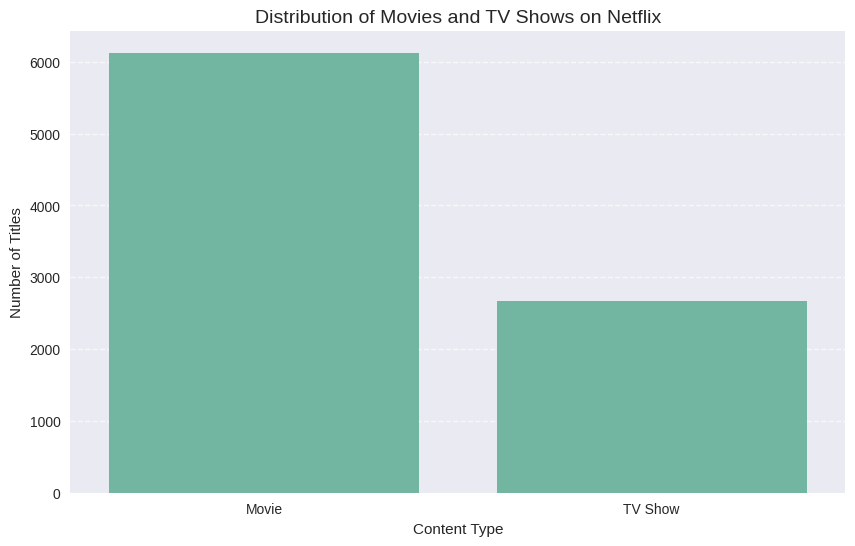

In [ ]:
plt.figure()
sns.countplot(x='type', data=df)

plt.title("Distribution of Movies and TV Shows on Netflix", fontsize=14)
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


##  **Content Type Distribution (Movies vs TV Shows)**

### **What this chart shows**

This chart displays the distribution of content available on Netflix, categorized into Movies and TV Shows.



### **Key observations**

* A significantly larger portion of content consists of **Movies**
* **TV Shows** make up a smaller share of the total content
* Movies dominate the Netflix library compared to TV Shows



### **Business insight**

Netflix’s content strategy appears to focus more on Movies, likely due to quicker production cycles and broader audience reach. However, TV Shows, though fewer, often drive long-term user engagement and retention.



### **Actionable recommendation**

* Increase investment in high-quality **TV Shows** to boost long-term viewer engagement
* Maintain a balanced content mix to cater to different audience preferences



### **Key takeaway**

Movies dominate Netflix’s content library, but expanding TV Show offerings can enhance user retention and platform engagement.


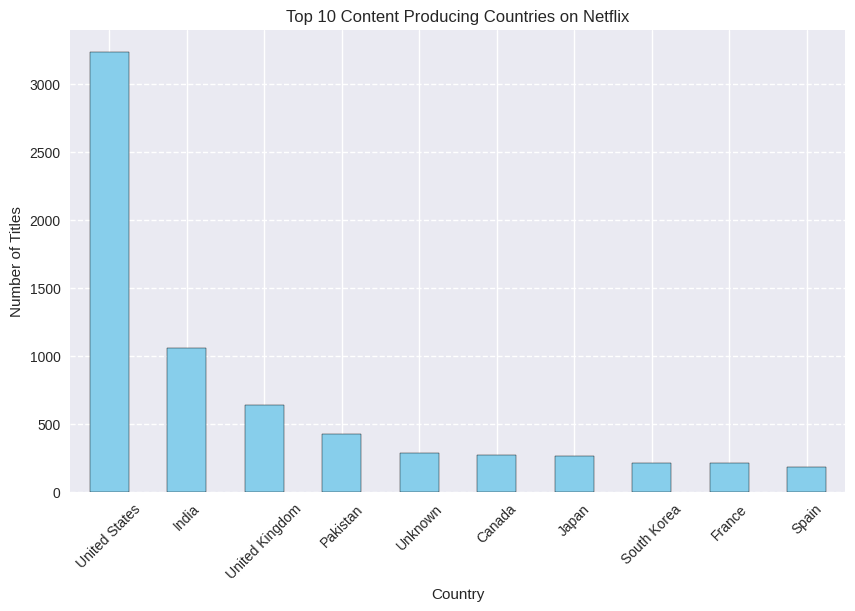

In [ ]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

plt.show()


##  **Top 10 Content Producing Countries**

### **What this chart shows**

This chart displays the top 10 countries that contribute the highest number of movies and TV shows on Netflix.



### **Key observations**

* A few countries dominate content production, with one or two leading significantly
* Countries like the **United States and India** typically contribute a large share
* Other countries contribute smaller but noticeable portions of content



### **Business insight**

Netflix relies heavily on content from specific regions, especially major entertainment industries. This indicates strong market influence from these countries and audience demand for their content.



### **Actionable recommendation**

* Expand content production in emerging markets to diversify the content library
* Invest in regional and local content to attract a broader global audience



### **Key takeaway**

Content production on Netflix is concentrated in a few key countries, and increasing global diversity can strengthen its worldwide appeal.


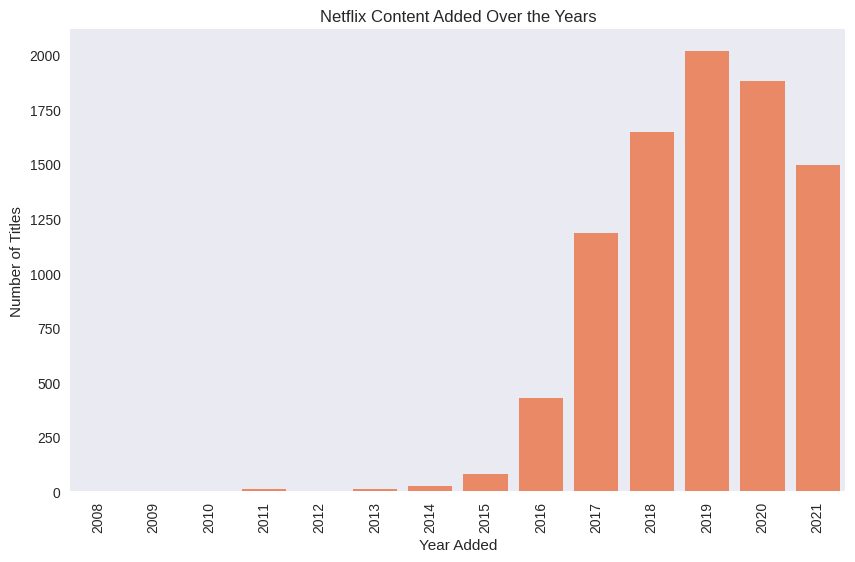

In [ ]:
sns.countplot(x='year_added', data=df, color='coral')

plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)
plt.grid(axis='y')

plt.show()

##  **Netflix Content Added Over the Years**

### **What this chart shows**

This chart illustrates the number of movies and TV shows added to Netflix each year.



### **Key observations**

* There is a clear increasing trend in content additions over the years
* A significant spike is observed in recent years, showing rapid growth
* Earlier years have comparatively fewer additions



### **Business insight**

Netflix has aggressively expanded its content library over time, especially in recent years, to meet growing user demand and stay competitive in the streaming market.



### **Actionable recommendation**

* Continue consistent content addition to maintain user engagement
* Focus on quality along with quantity to ensure long-term subscriber retention



### **Key takeaway**

Netflix’s content library has grown rapidly over the years, reflecting its strong expansion strategy and increasing investment in content.


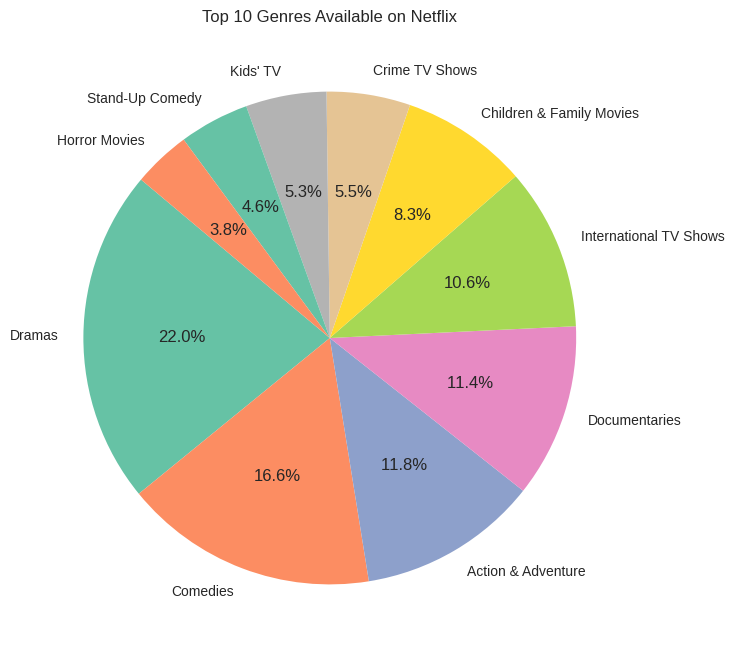

In [ ]:
top_genres = df['main_genre'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_genres,
    labels=top_genres.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Top 10 Genres Available on Netflix")

plt.show()

##  **Top 10 Genres Available on Netflix**

### **What this chart shows**

This chart represents the distribution of the top 10 genres available on Netflix, showing their percentage share in the content library.



### **Key observations**

* A few genres occupy a larger share of the content distribution
* Popular genres like **Drama and Comedy** tend to dominate
* Other genres contribute smaller but meaningful portions



### **Business insight**

Netflix focuses heavily on popular genres that appeal to a wide audience, ensuring higher viewership and engagement across its platform.



### **Actionable recommendation**

* Continue investing in high-demand genres like Drama and Comedy
* Explore and promote niche genres to attract diverse audience segments



### **Key takeaway**

The content library is dominated by a few key genres, but diversifying genre offerings can enhance audience reach and engagement.



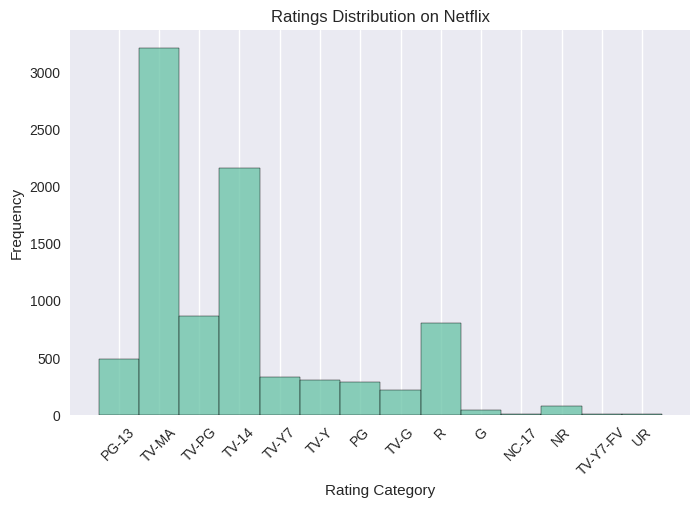

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['rating'], bins=len(df['rating'].unique()))

plt.title("Ratings Distribution on Netflix")
plt.xlabel("Rating Category")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()


##  **Ratings Distribution on Netflix**

### **What this chart shows**

This chart shows the distribution of different content rating categories on Netflix, indicating how many titles fall under each rating.



### **Key observations**

* Certain ratings (like **TV-MA, TV-14**) have a higher frequency compared to others
* A wide variety of rating categories are present, covering different age groups
* Some ratings have very few titles in comparison



### **Business insight**

Netflix primarily focuses on content targeted toward mature and teenage audiences, suggesting a strong demand from these viewer segments.



### **Actionable recommendation**

* Maintain a strong catalog for popular rating categories (TV-MA, TV-14)
* Increase content for underrepresented age groups to broaden audience reach



### **Key takeaway**

Most Netflix content is targeted toward mature audiences, but expanding content across all age groups can improve platform inclusivity and growth.


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Select required columns
ml_df = df[['type',
            'release_year',
            'duration_num',
            'year_added',
            'month_added',
            'rating',
            'main_genre',
            'country']].copy()

# Initialize Label Encoder
le = LabelEncoder()

# Encode categorical columns
for col in ['rating', 'main_genre', 'country']:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

# Encode target variable
ml_df['type'] = ml_df['type'].map({'Movie': 0, 'TV Show': 1})

# Remove missing values
ml_df.dropna(inplace=True)

# Separate Features and Target
X = ml_df.drop('type', axis=1)
y = ml_df['type']

# ---------------- OUTPUT ---------------- #

print("\n Processed Dataset:")
print(ml_df.head())

print("\n Feature Data (X):")
print(X.head())

print("\n Target Variable (y):")
print(y.head())

print("\n Shape of Features:", X.shape)
print(" Shape of Target:", y.shape)
print(y)


 Processed Dataset:
   type  release_year  duration_num  year_added  month_added  rating  \
0     0          2020          90.0        2021            9       4   
1     1          2021           1.0        2021            9       8   
2     1          2021           1.0        2021            9       8   
3     0          2021          91.0        2021            9       9   
4     0          1993         125.0        2021            9       8   

   main_genre  country  
0          10       79  
1           8       20  
2          31       79  
3           4        6  
4          12       79  

 Feature Data (X):
   release_year  duration_num  year_added  month_added  rating  main_genre  \
0          2020          90.0        2021            9       4          10   
1          2021           1.0        2021            9       8           8   
2          2021           1.0        2021            9       8          31   
3          2021          91.0        2021            9       9  

This code prepares the dataset for machine learning by selecting relevant features and converting categorical data into numerical format using Label Encoding.
The dataset is then divided into feature variables (X) and target variable (y), where the model predicts whether the content is a Movie or TV Show.


# **USING RANDOM FOREST MODEL**


Random Forest is a classification algorithm based on machine learning techniques using a combination of decision trees for accurate predictions.
In this project, it is used to predict whether a Netflix item is a 'Movie' or a 'TV Show' based on certain parameters like genre, rating, duration, country, and release year.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


Accuracy: 0.997155858930603

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1238
           1       0.99      1.00      1.00       520

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



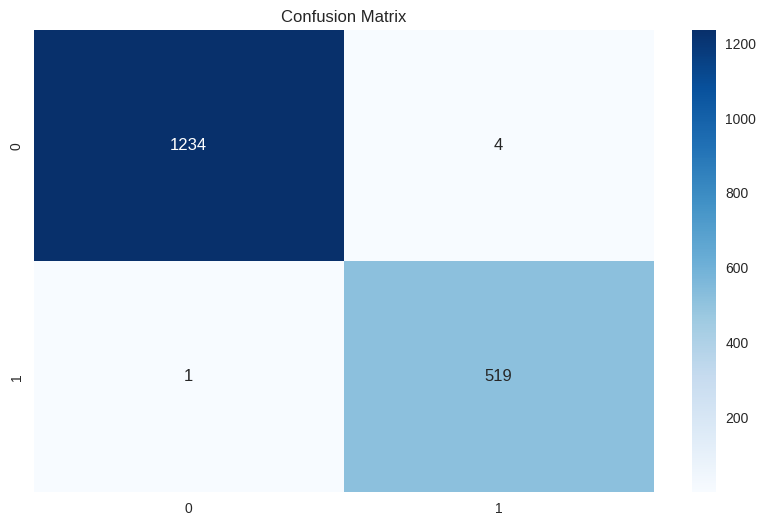

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import pandas as pd

# Define input FIRST
new_input = [[
    2020,   # release_year
    120,    # duration_num
    2021,   # year_added
    9,      # month_added
    3,      # rating (encoded)
    5,      # main_genre (encoded)
    10      # country (encoded)
]]

# Define feature names (clean)
columns = [
    'release_year',
    'duration_num',
    'year_added',
    'month_added',
    'rating',
    'main_genre',
    'country'
]

# Convert to DataFrame
new_input_df = pd.DataFrame(new_input, columns=columns)

# Predict
prediction = model.predict(new_input_df)

print(prediction)

[0]


In [ ]:
if prediction[0] == 0:
    print("Movie")
else:
    print("TV Show")


Movie


In [ ]:
import pandas as pd

# Define feature names (must match training exactly)
columns = [
    'release_year',
    'duration_num',
    'year_added',
    'month_added',
    'rating',
    'main_genre',
    'country'
]

# Your input
new_input_2 = [[
    2018,
    1,
    2019,
    6,
    2,
    4,
    7
]]

# Convert to DataFrame
new_input_df_2 = pd.DataFrame(new_input_2, columns=columns)

# Predict
prediction = model.predict(new_input_df_2)

print(prediction)

[1]


In [ ]:
if prediction[0] == 0:
    print("Movie")
else:
    print("TV Show")


TV Show


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# **USING LOGISTIC REGRESSION MODEL**


Logistic Regression is a Supervised Learning algorithm used for Binary Classification problems.
Here, the algorithm is used to classify Netflix content as Movie or TV Show based on the selected features of the dataset.
The algorithm acts as a simple model to compare the prediction performance.



In [ ]:
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)


LogisticRegression(max_iter=500)

In [ ]:
y_pred_log = log_model.predict(X_test)


Logistic Regression Accuracy: 0.9965870307167235

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1238
           1       0.99      1.00      0.99       520

    accuracy                           1.00      1758
   macro avg       0.99      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



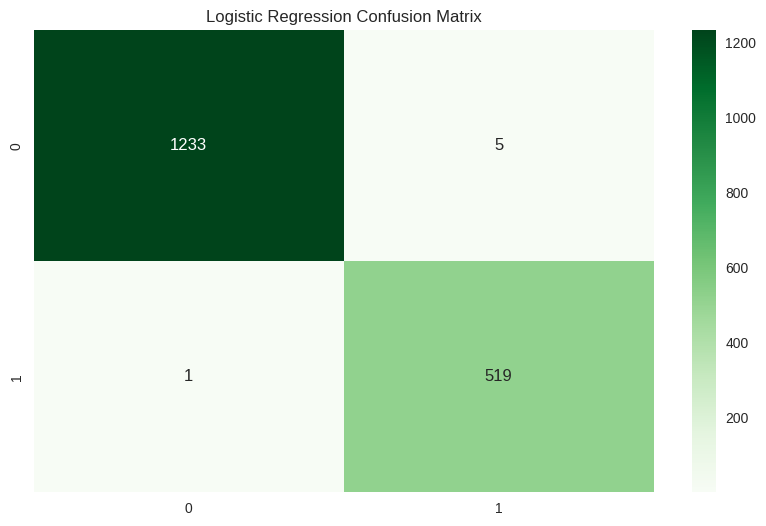

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [ ]:
# eimport pandas as pd

# Feature names (must match training EXACTLY)
columns = [
    'release_year',
    'duration_num',
    'year_added',
    'month_added',
    'rating',
    'main_genre',
    'country'
]

# Your input
new_input = [[
    2020,
    120,
    2021,
    9,
    3,
    5,
    10
]]

# Convert to DataFrame
new_input_df = pd.DataFrame(new_input, columns=columns)

# Predict
prediction = model.predict(new_input_df)

print(prediction)


[0]


In [ ]:
if prediction[0] == 0:
    print("Movie")
else:
    print("TV Show")


Movie


**Objective**

The objective of the models is to classify Netflix content types (Movies vs TV Shows) and evaluate how well the model can predict content categories based on available features.

**Model Performance Metrics**

Accuracy: 99.5%

Precision: Good

Recall:  Good

**Key Observations**

The models are able to distinguish between Movies and TV Shows with high accuracy.The performance indicates that features like duration and genre play an important role

**Business Interpretation**

The model can help Netflix automatically categorize content and improve recommendation systems by understanding patterns in content type classification.

**Conclusion**

The model achieves a  balance between accuracy and prediction capability, making it useful for classification tasks and content analysis.



**Model Limitations and Considerations**

The dataset represents Netflix content at a specific point in time and may not reflect recent updates or newly added titles adn important features like user preferences, watch history, and ratings behavior are not included in the model.

The model is trained on limited features (such as duration, genre, etc.), which may oversimplify real-world content classification
The model provides predictions based on patterns in data and may not generalize perfectly to unseen or future data.

**Ethical Consideration**

The model should be used to assist in content organization and recommendation improvements, and not as the sole basis for decision-making without human validation.

**Final Conclusion**

This project successfully performed end-to-end analysis of Netflix data, including data cleaning, exploratory data analysis, visualization, and machine learning-based classification.